In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

In [ ]:
alpha = 0.33    # Capital share
beta = 0.99     # Discount factor
gamma = 2       # Preference parameter (not used here)
eta = 1         # Labor disutility parameter (not used directly here)
chi = 7.88     # Scaling parameter (can apply if utility includes labor supply)
delta = 0.025   # Depreciation rate
phi = 2         # Adjustment cost parameter
rho = 0.    # Persistence of technology shocks
sigma_eps = 0.1  # Standard deviation of shocks        ### IS O.1 no? 
A_ss = 1
N_ss = 1/3
q_ss = 1

# System of equations to solve for steady-state variables
def steady_state(vars):
    K_ss, I_ss, C_ss, w_ss = vars  # r_SS is defined directly via the formula
    
    # Rental rate of capital at steady state
    r_ss = 1 / beta - 1 + delta  # This is fixed as per your formula
    
    # Output at steady state
    Y_ss = A_ss * K_ss**alpha * N_ss**(1 - alpha)
    
    # Equations
    eq1 = Y_ss - (C_ss + I_ss)  # Resource constraint
    eq2 = I_ss - delta * K_ss  # Investment equation
    eq3 = w_ss - A_ss * (1 - alpha) * (K_ss / N_ss)**alpha  # Wage equation
    eq4 = r_ss - A_ss * alpha * (N_ss / K_ss)**(1 - alpha)  # Rental rate consistency
    
    return [eq1, eq2, eq3, eq4]

# Initial guesses for K_ss, I_SS, C_ss, w_SS
initial_guess = [9, 0.25, 0.5, 1]

# Solve the system of equations
K_ss, I_ss, C_ss, w_ss = fsolve(steady_state, initial_guess)

# Rental rate and output at steady state
r_ss = 1 / beta - 1 + delta
Y_ss = A_ss * K_ss**alpha * N_ss**(1 - alpha)

print("Steady-state values:")
print(f"K_ss = {K_ss}, I_ss = {I_ss}, C_ss = {C_ss}, r_SS = {r_ss}, w_SS = {w_ss}, Y_SS = {Y_ss}")

# Time horizon
T = 200

# Initialize arrays
log_A_t = np.zeros(T)
A_t = np.ones(T) * A_ss  # Technology shock array
K_t = np.ones(T) * K_ss  # Capital
C_t = np.ones(T) * C_ss  # Consumption
N_t = np.ones(T) * N_ss  # Labor
Y_t = np.ones(T) * Y_ss  # Output
w_t = np.ones(T) * w_ss  # Wages
I_t = np.ones(T) * I_ss  # Investment
r_t = np.ones(T) * r_ss  # Return on capital

#Tech shock
log_A_t[0] = np.log(1.0)  # Initial steady-state technology level
log_A_t[1] = rho * log_A_t[0] + sigma_eps  # Apply shock at t=1
for t in range(2, T):
    log_A_t[t] = rho * log_A_t[t-1]  # Continue the AR(1) process
A_t = np.exp(log_A_t)


#here i put all of them together in one system. 
def system_solve(x, A_t, alpha, beta, delta, chi, eta, T):
    C_t = x[0:T]
    K_t = x[T:2*T]      # ATTENTION HERE.... Not the correct order to unpack. DONE slicing is always one less hence then it says ends at it its actually T-1 
    N_t = x[2*T:3*T]
    error = np.zeros(3*T)


    #IMPOSE THE RIGHT BOUNDARY CONDITIONS: such that you feel the errors missing DONE
    # error at 2T-1 with final value of capital minus capital at ss              DONE
    # error in the end: initial value of capital minus capital at ss             DONE

    #Boundary condition, final value
    error[(2*T)-1] = K_t[T-1]-K_ss                        #refering to cell 399 final coniditon        DONE
    error[T*3-1] = K_t[0]-K_ss                             #refering to 200   inital coniditon           DONE

    # Labor Condition Error loop
    # MISTAKE HERE---- CONTROL THIS!!!!!! HERE STILL MISTAKE ?
    for t in range (0, T): #should be T                                             DONE
        error[t] = chi * N_t[t]**eta * C_t[t] - (1-alpha)*A_t[t]*K_t[t]**alpha*N_t[t]**(-alpha)
        # Euler Equation Error loop 
    for t in range (0, T-1):
        error[T + t] = 1 - beta * (C_t[t] / C_t[t+1]) * ((alpha*A_t[t+1]*K_t[t+1]**(alpha-1)*N_t[t+1]**(1-alpha)) + (1 - delta))
        # Resource Constraint Error loop check it 
    for t in range(0, T-1):  # Correct loop range
        error[(2*T) + t] = C_t[t] + K_t[t+1] - (1 - delta) * K_t[t] - A_t[t] * K_t[t]**alpha * N_t[t]**(1 - alpha)


    # Return errors
    return error


initial_guess = [C_t, K_t, N_t]
initial_guess = np.array(initial_guess)
initial_guess = initial_guess.flatten()

# Solve the system
solution = fsolve(system_solve, initial_guess, args=(A_t, alpha, beta, delta, chi, eta, T))




C_t = solution[0:T]
K_t = solution[T:2*T]
N_t = solution[2*T:3*T]

# Print the results for verification
print("C_t:", C_t)
print("K_t:", K_t)
print("N_t:", N_t)

# Optionally, check if the errors are near zero
errors = system_solve(solution, A_t, alpha, beta, delta, chi, eta, T)
print("Max error:", np.max(np.abs(errors)))

Steady-state values:
K_ss = 9.449473020349593, I_ss = 0.23623682550873984, C_ss = 0.7688724106625053, r_SS = 0.03510101010101017, w_SS = 2.020269564704203, Y_SS = 1.0051092361712468
C_t: [0.77952749 0.78365699 0.78660148 0.78864103 0.78998751 0.79080278
 0.79121143 0.79130993 0.79117331 0.79086007 0.79041593 0.78987661
 0.78927006 0.78861806 0.78793758 0.78724179 0.78654083 0.78584247
 0.78515262 0.78447568 0.78381489 0.78317259 0.78255037 0.78194926
 0.78136986 0.78081242 0.78027693 0.77976317 0.77927077 0.77879927
 0.77834811 0.77791666 0.77750429 0.77711031 0.77673403 0.77637478
 0.77603186 0.77570461 0.77539236 0.77509447 0.77481031 0.77453929
 0.77428082 0.77403433 0.77379929 0.77357518 0.7733615  0.77315777
 0.77296353 0.77277835 0.77260181 0.77243352 0.77227308 0.77212014
 0.77197434 0.77183536 0.77170288 0.77157659 0.7714562  0.77134145
 0.77123206 0.7711278  0.77102841 0.77093367 0.77084337 0.77075729
 0.77067524 0.77059703 0.77052249 0.77045143 0.7703837  0.77031914
 0.770257

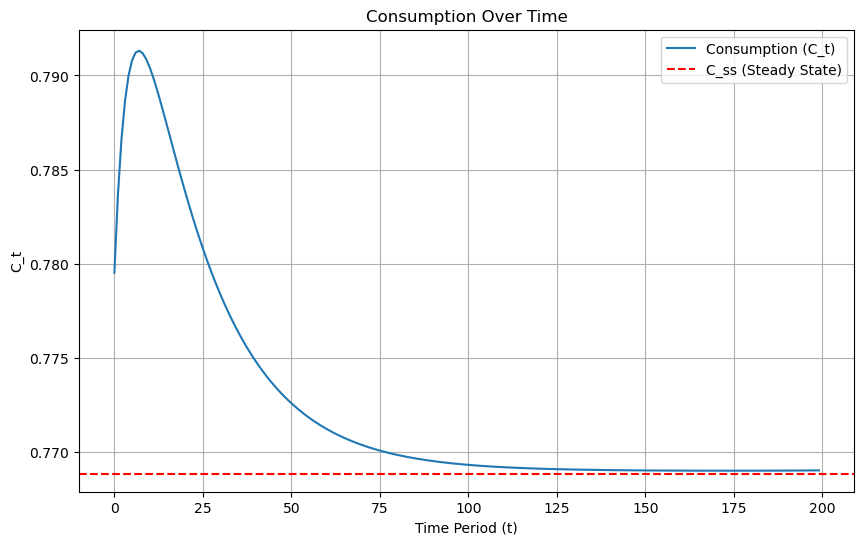

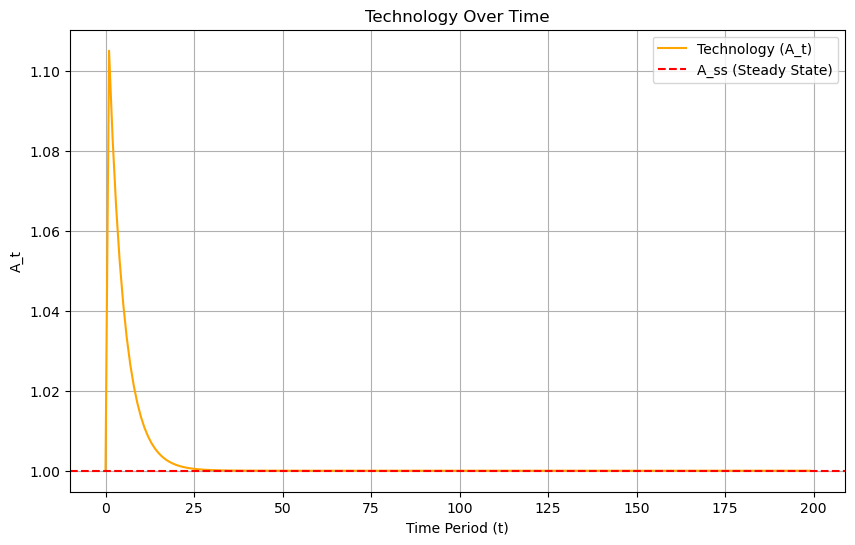

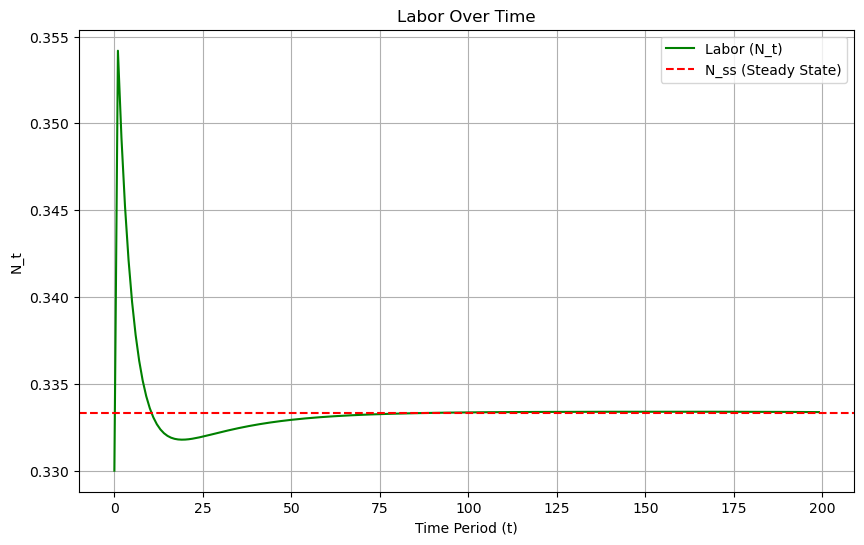

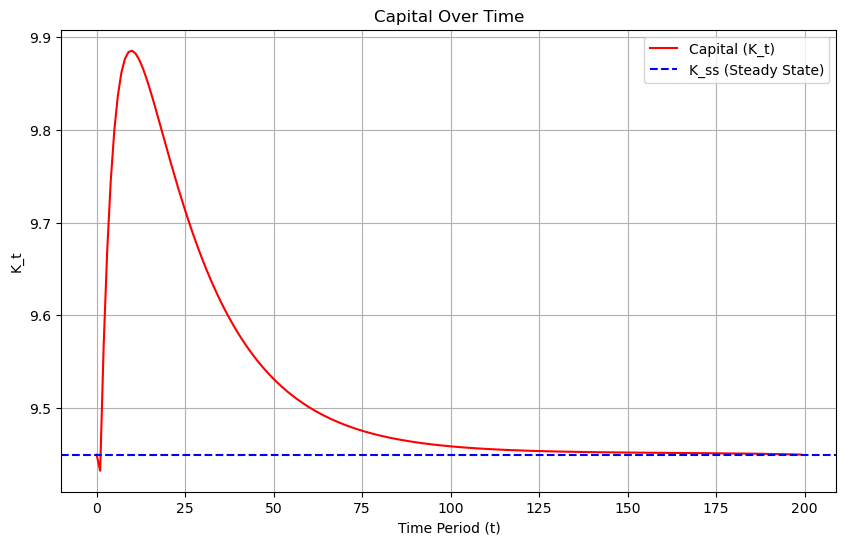

In [31]:
# Plot Consumption (C_t)
plt.figure(figsize=(10, 6))
plt.plot(range(T), C_t, label='Consumption (C_t)')
plt.axhline(y=C_ss, color='red', linestyle='--', label='C_ss (Steady State)')
plt.xlabel('Time Period (t)')
plt.ylabel('C_t')
plt.title('Consumption Over Time')
plt.grid(True)
plt.legend()
plt.show()

# Plot Technology (A_t)
plt.figure(figsize=(10, 6))
plt.plot(range(T), A_t, label='Technology (A_t)', color='orange')
plt.axhline(y=A_ss, color='red', linestyle='--', label='A_ss (Steady State)')
plt.xlabel('Time Period (t)')
plt.ylabel('A_t')
plt.title('Technology Over Time')
plt.grid(True)
plt.legend()
plt.show()

# Plot Labor (N_t)
plt.figure(figsize=(10, 6))
plt.plot(range(T), N_t, label='Labor (N_t)', color='green')
plt.axhline(y=N_ss, color='red', linestyle='--', label='N_ss (Steady State)')
plt.xlabel('Time Period (t)')
plt.ylabel('N_t')
plt.title('Labor Over Time')
plt.grid(True)
plt.legend()
plt.show()

# Plot Capital (K_t)
plt.figure(figsize=(10, 6))
plt.plot(range(T), K_t, label='Capital (K_t)', color='red')
plt.axhline(y=K_ss, color='blue', linestyle='--', label='K_ss (Steady State)')
plt.xlabel('Time Period (t)')
plt.ylabel('K_t')
plt.title('Capital Over Time')
plt.grid(True)
plt.legend()
plt.show()


In [37]:
# Output (Y_t)
Y_t = A_t * K_t**alpha * N_t**(1 - alpha)

# Wages (w_t)
w_t = (1 - alpha) * A_t * K_t**alpha * N_t**(-alpha)

# Interest Rate (r_t)
r_t = alpha * A_t * K_t**(alpha - 1) * N_t**(1 - alpha)

# Tobin's q (q_t)
q_t = 1 / (1 - phi * ((I_t / K_t) - delta))

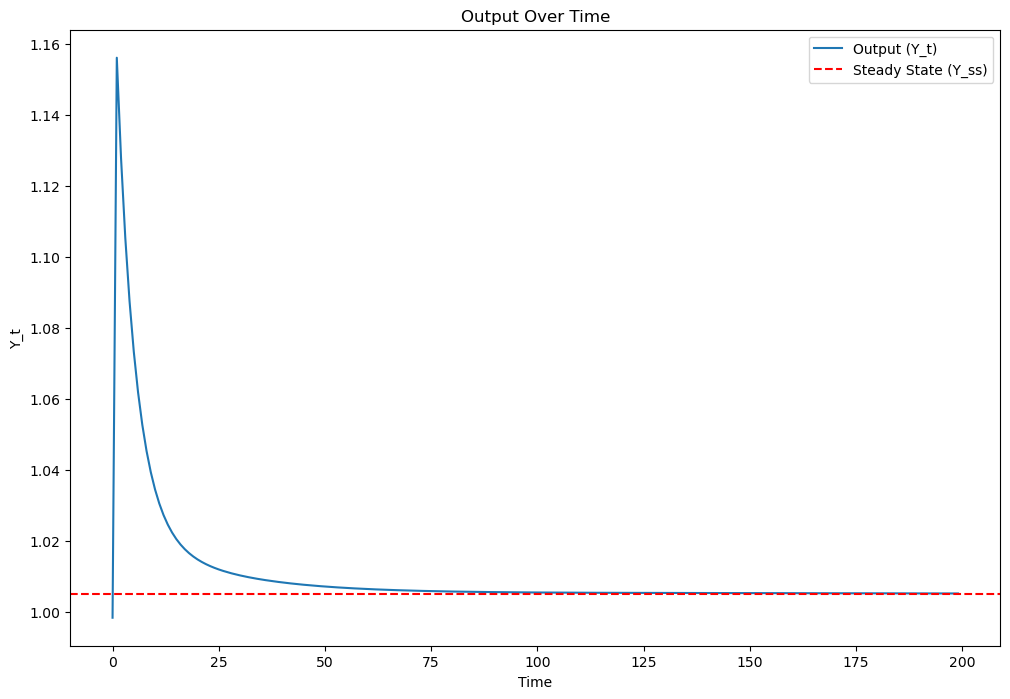

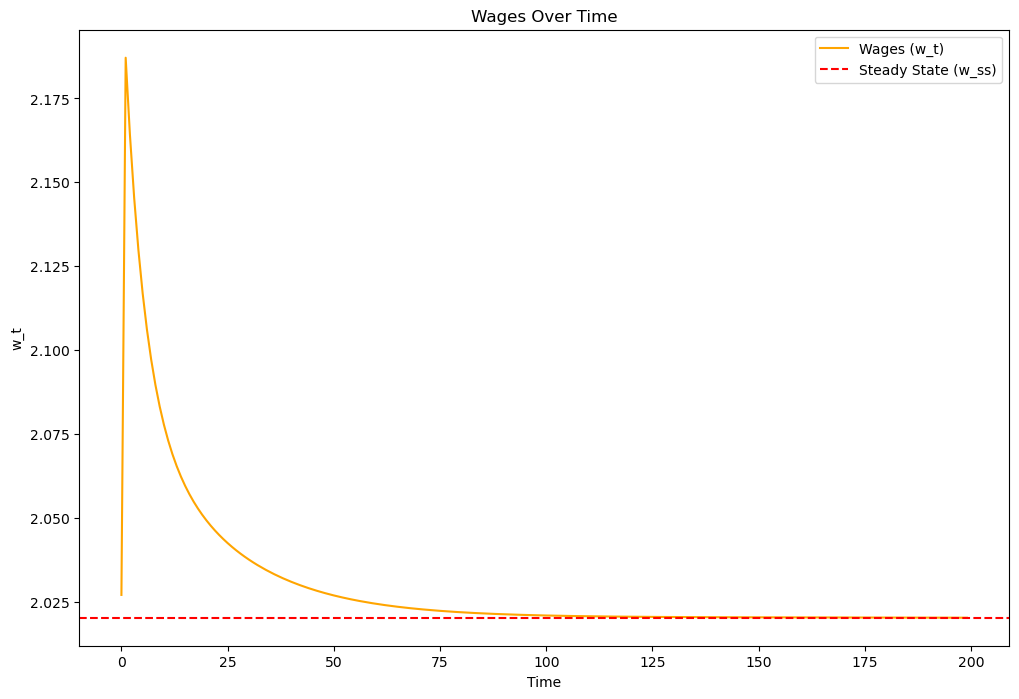

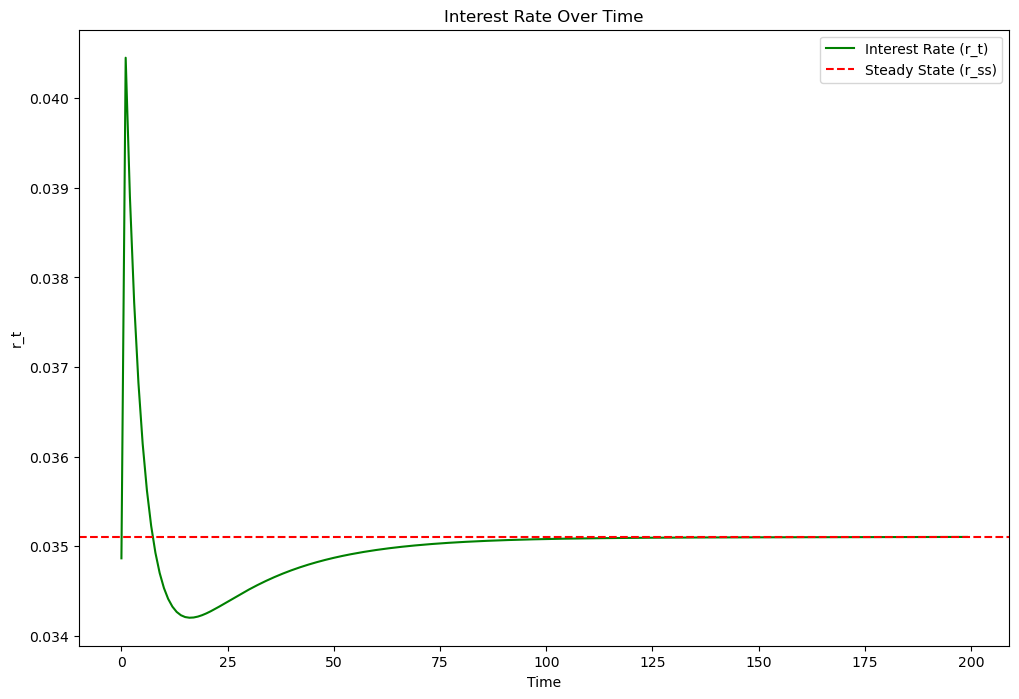

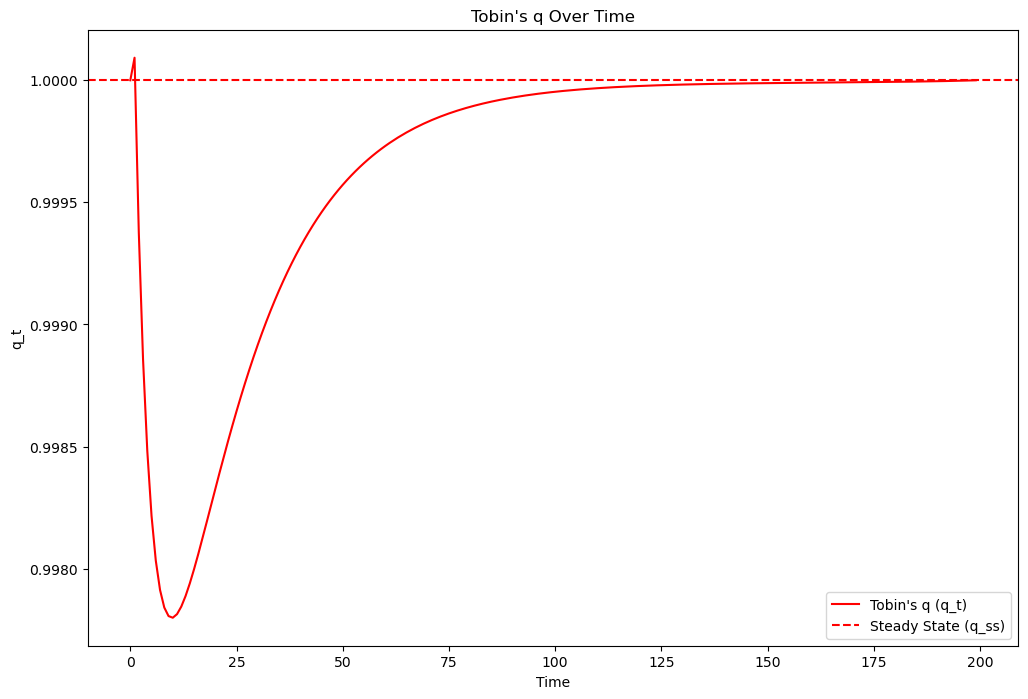

In [38]:
# Plot Output
plt.figure(figsize=(12, 8))
plt.plot(Y_t, label="Output (Y_t)")
plt.axhline(Y_ss, color="red", linestyle="--", label="Steady State (Y_ss)")
plt.title("Output Over Time")
plt.xlabel("Time")
plt.ylabel("Y_t")
plt.legend()
plt.show()

# Plot Wages
plt.figure(figsize=(12, 8))
plt.plot(w_t, label="Wages (w_t)", color="orange")
plt.axhline(w_ss, color="red", linestyle="--", label="Steady State (w_ss)")
plt.title("Wages Over Time")
plt.xlabel("Time")
plt.ylabel("w_t")
plt.legend()
plt.show()

# Plot Interest Rate
plt.figure(figsize=(12, 8))
plt.plot(r_t, label="Interest Rate (r_t)", color="green")
plt.axhline(r_ss, color="red", linestyle="--", label="Steady State (r_ss)")
plt.title("Interest Rate Over Time")
plt.xlabel("Time")
plt.ylabel("r_t")
plt.legend()
plt.show()

# Plot Tobin's q
plt.figure(figsize=(12, 8))
plt.plot(q_t, label="Tobin's q (q_t)", color="red")
plt.axhline(q_ss, color="red", linestyle="--", label="Steady State (q_ss)")
plt.title("Tobin's q Over Time")
plt.xlabel("Time")
plt.ylabel("q_t")
plt.legend()
plt.show()